In [ ]:
from pathlib import Path

print("Esiste /content/drive:", Path("/content/drive").exists())
print("Esiste MyDrive:", Path("/content/drive/MyDrive").exists())

Esiste /content/drive: False
Esiste MyDrive: False


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

for p in Path("/content/drive/MyDrive").rglob("deepfake_training.zip"):
    print(p)

/content/drive/MyDrive/deepfake-thesis/deepfake_training.zip


In [ ]:
import zipfile
from pathlib import Path

zip_path = Path(
    "/content/drive/MyDrive/deepfake-thesis/deepfake_training.zip"
)

extract_dir = Path(
    "/content/deepfake-thesis"
)

extract_dir.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Estrazione completata.")

Estrazione completata.


In [ ]:
from pathlib import Path

src = Path("/content/deepfake-thesis/src")

print("dataset.py:", (src / "dataset.py").exists())
print("dataloaders.py:", (src / "dataloaders.py").exists())
print("models.py:", (src / "models.py").exists())
print("train_xception.py:", (src / "train_xception.py").exists())

print("\nNumero crop:")
print(
    len(
        list(
            Path(
                "/content/deepfake-thesis/data_processed/faces"
            ).glob("*.png")
        )
    )
)

print(
    "\ndataset_splits.csv:",
    Path(
        "/content/deepfake-thesis/metadata/dataset_splits.csv"
    ).exists()
)

dataset.py: True
dataloaders.py: True
models.py: True
train_xception.py: True

Numero crop:
49653

dataset_splits.csv: True


In [ ]:
from pathlib import Path
import shutil

project = Path("/content/deepfake-thesis")
src = project / "src"

drive_script = Path(
    "/content/drive/MyDrive/deepfake-thesis/src/train_efficientnet.py"
)

local_script = src / "train_efficientnet.py"

print("Cartella progetto:", project.exists())
print("dataset.py:", (src / "dataset.py").exists())
print("dataloaders.py:", (src / "dataloaders.py").exists())
print("models.py:", (src / "models.py").exists())
print("train_efficientnet.py su Drive:", drive_script.exists())

if drive_script.exists():
    shutil.copy2(drive_script, local_script)
    print("\nEfficientNet copiato nel progetto.")
    print("train_efficientnet.py locale:", local_script.exists())
else:
    print("\nATTENZIONE: train_efficientnet.py non è ancora presente su Drive.")

Cartella progetto: True
dataset.py: True
dataloaders.py: True
models.py: True
train_efficientnet.py su Drive: True

EfficientNet copiato nel progetto.
train_efficientnet.py locale: True


In [ ]:
from pathlib import Path
import os
import shutil

project = Path("/content/deepfake-thesis")

drive_run = Path(
    "/content/drive/MyDrive/deepfake-thesis/efficientnet_b4_baseline"
)

drive_models = drive_run / "models"
drive_results = drive_run / "results"

drive_models.mkdir(parents=True, exist_ok=True)
drive_results.mkdir(parents=True, exist_ok=True)

for name, target in [
    ("models", drive_models),
    ("results", drive_results),
]:
    local = project / name

    if local.is_symlink():
        local.unlink()

    elif local.exists():
        # Non cancelliamo nulla se contiene file.
        if any(local.iterdir()):
            print(
                f"ATTENZIONE: {local} contiene file. "
                "Non è stata modificata."
            )
            continue
        else:
            local.rmdir()

    os.symlink(target, local)

    print(
        f"{name} -> {local.resolve()}"
    )

models -> /content/drive/MyDrive/deepfake-thesis/efficientnet_b4_baseline/models
results -> /content/drive/MyDrive/deepfake-thesis/efficientnet_b4_baseline/results


In [ ]:
%cd /content/deepfake-thesis
!python -u src/train_efficientnet.py --smoke-test --num-workers 2

/content/deepfake-thesis
File su Drive trovato: True
File copiato: True


In [ ]:
!pip -q install timm

In [ ]:
from pathlib import Path
import shutil

drive_script = Path(
    "/content/drive/MyDrive/deepfake-thesis/src/train_efficientnet.py"
)

local_script = Path(
    "/content/deepfake-thesis/src/train_efficientnet.py"
)

shutil.copy2(
    drive_script,
    local_script
)

print("Copiato:", local_script.exists())

Copiato: True


In [ ]:
%cd /content/deepfake-thesis
!python -u src/train_efficientnet.py --smoke-test --num-workers 2

/content/deepfake-thesis
File su Drive trovato: True
File copiato: True


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA disponibile: True
GPU: Tesla T4


In [ ]:
import torch
from pathlib import Path

print("GPU:", torch.cuda.get_device_name(0))

print(
    "Progetto presente:",
    Path("/content/deepfake-thesis").exists()
)

print(
    "ZIP su Drive presente:",
    Path(
        "/content/drive/MyDrive/deepfake-thesis/deepfake_training.zip"
    ).exists()
)

GPU: Tesla T4
Progetto presente: True
ZIP su Drive presente: True


In [ ]:
%cd /content/deepfake-thesis

import sys
import gc
import torch
import torch.nn as nn

sys.path.insert(0, "/content/deepfake-thesis/src")

from dataloaders import create_dataloaders
from models import create_model
from train_efficientnet import (
    calculate_class_weights,
    train_one_epoch,
)

device = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))

# Pulizia memoria
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Dataset con preprocessing EfficientNet-B4
train_loader, _, _ = create_dataloaders(
    model_name="efficientnet_b4",
    batch_size=32,
    num_workers=2,
)

# Modello temporaneo
model = create_model(
    model_name="efficientnet_b4",
    pretrained=True,
    num_classes=2,
).to(device)

# Stessi pesi usati nel training vero
class_weights = calculate_class_weights(
    train_loader.dataset,
    device,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True,
)

# UN SOLO batch con forward + backward + optimizer step
metrics = train_one_epoch(
    model=model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    scaler=scaler,
    use_amp=True,
    max_batches=1,
)

print("\nTest batch 32 completato.")
print("Loss:", metrics["loss"])

print(
    "Picco VRAM:",
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
)

# Eliminiamo il modello temporaneo
del model
del optimizer
del criterion
del scaler

gc.collect()
torch.cuda.empty_cache()

/content/deepfake-thesis
File su Drive trovato: True
File copiato: True


ImportError: cannot import name 'calculate_class_weights' from 'train_efficientnet' (/content/deepfake-thesis/src/train_efficientnet.py)

In [ ]:
from google.colab import files
from pathlib import Path

uploaded = files.upload()

uploaded_name = next(iter(uploaded))

destination = Path(
    "/content/deepfake-thesis/src/train_efficientnet.py"
)

destination.write_bytes(
    uploaded[uploaded_name]
)

print("File salvato in:", destination)
print("Dimensione:", destination.stat().st_size, "byte")

Saving train_efficientnet.py to train_efficientnet.py
File salvato in: /content/deepfake-thesis/src/train_efficientnet.py
Dimensione: 29324 byte


In [ ]:
!grep -n "def calculate_class_weights" /content/deepfake-thesis/src/train_efficientnet.py
!grep -n "def train_one_epoch" /content/deepfake-thesis/src/train_efficientnet.py
!grep -n "def validate" /content/deepfake-thesis/src/train_efficientnet.py

165:def calculate_class_weights(train_dataset, device):
349:def train_one_epoch(
528:def validate(


In [ ]:
import sys
import importlib

# Elimina dalla memoria la vecchia versione del modulo
if "train_efficientnet" in sys.modules:
    del sys.modules["train_efficientnet"]

importlib.invalidate_caches()

import train_efficientnet

print(
    "calculate_class_weights:",
    hasattr(train_efficientnet, "calculate_class_weights")
)

print(
    "train_one_epoch:",
    hasattr(train_efficientnet, "train_one_epoch")
)

print(
    "validate:",
    hasattr(train_efficientnet, "validate")
)

calculate_class_weights: True
train_one_epoch: True
validate: True


In [ ]:
%cd /content/deepfake-thesis

import sys
import gc
import torch
import torch.nn as nn

sys.path.insert(0, "/content/deepfake-thesis/src")

from dataloaders import create_dataloaders
from models import create_model
from train_efficientnet import (
    calculate_class_weights,
    train_one_epoch,
)

device = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

train_loader, _, _ = create_dataloaders(
    model_name="efficientnet_b4",
    batch_size=32,
    num_workers=2,
)

model = create_model(
    model_name="efficientnet_b4",
    pretrained=True,
    num_classes=2,
).to(device)

class_weights = calculate_class_weights(
    train_loader.dataset,
    device,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True,
)

metrics = train_one_epoch(
    model=model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    scaler=scaler,
    use_amp=True,
    max_batches=1,
)

print("\nTest batch 32 completato.")
print("Loss:", metrics["loss"])

print(
    "Picco VRAM:",
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
)

del model
del optimizer
del criterion
del scaler

gc.collect()
torch.cuda.empty_cache()

/content/deepfake-thesis
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 185MB/s]



Distribuzione training set:
REAL (0): 7164
FAKE (1): 28605

Pesi CrossEntropyLoss:
REAL: 2.4964
FAKE: 0.6252

Test batch 32 completato.
Loss: 0.7004054188728333
Picco VRAM: 10.01 GB


In [ ]:
%cd /content/deepfake-thesis
!python -u src/train_efficientnet.py --batch-size 32 --num-workers 2

/content/deepfake-thesis
TRAINING EFFICIENTNET-B4 BASELINE

Device: cuda
GPU: Tesla T4
Batch size: 32
Epoche massime: 20

Training samples: 35769
Validation samples: 6990

Distribuzione training set:
REAL (0): 7164
FAKE (1): 28605

Pesi CrossEntropyLoss:
REAL: 2.4964
FAKE: 0.6252

Mixed precision: True

EPOCA 1/20

TRAIN
Loss:      0.3643
Accuracy:  0.8352
Precision: 0.9421
Recall:    0.8459
F1:        0.8915
ROC-AUC:   0.9149

VALIDATION
Loss:      0.1957
Accuracy:  0.9240
Precision: 0.9729
Recall:    0.9309
F1:        0.9515
ROC-AUC:   0.9704

Learning rate: 0.00010000
Tempo epoca: 832.8 secondi

Nuova migliore validation loss.
Checkpoint salvato in:
/content/deepfake-thesis/models/efficientnet_b4_baseline_best.pth

EPOCA 2/20

TRAIN
Loss:      0.1438
Accuracy:  0.9438
Precision: 0.9865
Recall:    0.9426
F1:        0.9641
ROC-AUC:   0.9868

VALIDATION
Loss:      0.2025
Accuracy:  0.9348
Precision: 0.9782
Recall:    0.9394
F1:        0.9584
ROC-AUC:   0.9760

Learning rate: 0.00010000

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
files = list(
    Path("/content/drive/MyDrive").rglob(
        "efficientnet_b4_baseline_history.csv"
    )
)

files

[PosixPath('/content/drive/MyDrive/deepfake-thesis/efficientnet_b4_baseline/results/efficientnet_b4_baseline_history.csv')]

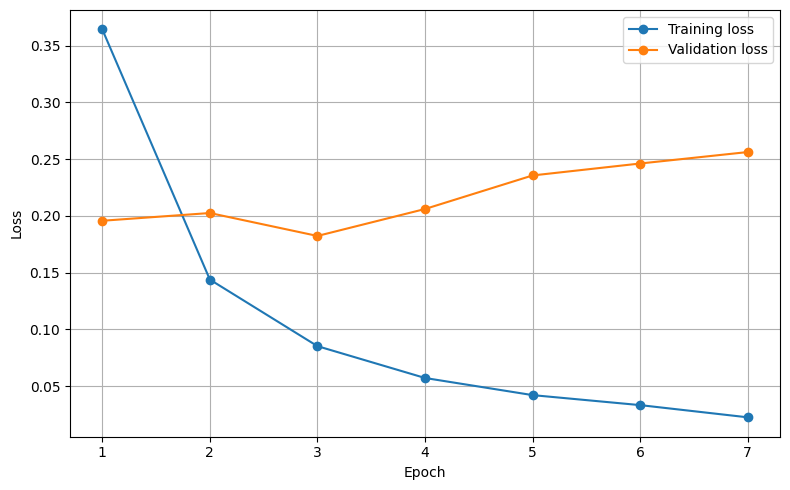

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(
    "/content/drive/MyDrive/deepfake-thesis/efficientnet_b4_baseline/results/efficientnet_b4_baseline_history.csv"
)

plt.figure(figsize=(8, 5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
files = list(
    Path("/content/drive/MyDrive").rglob("dataloaders.py")
)

files

[PosixPath('/content/drive/MyDrive/deepfake-thesis/src/dataloaders.py')]

In [ ]:
!ls -la /content/drive/MyDrive/deepfake-thesis/src

total 209
drwx------ 3 root root  4096 Sep 11 15:14 .
drwx------ 5 root root  4096 Aug 19 13:48 ..
-rw------- 1 root root  8330 Aug 19 13:00 dataloaders.py
-rw------- 1 root root  7983 Sep 11 14:18 models.py
drwx------ 2 root root  4096 Sep 11 15:14 __pycache__
-rw------- 1 root root 97171 Sep 11 15:15 train_efficientnet.ipynb
-rw------- 1 root root   376 Sep 11 10:00 train_efficientnet.py
-rw------- 1 root root 86795 Sep 11 15:09 train_xception.ipynb


In [ ]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

SRC_DIR = PROJECT_ROOT / "src"
DATASET_FILE = SRC_DIR / "dataset.py"

print("SRC_DIR:", SRC_DIR)
print("dataset.py esiste:", DATASET_FILE.exists())

print("\nFile presenti in src:")
for f in SRC_DIR.iterdir():
    print("-", f.name)

# Aggiunge src al path
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Importante: aggiorna la cache dopo aver aggiunto dataset.py
importlib.invalidate_caches()

from dataset import FaceForensicsDataset
from dataloaders import create_dataloaders
from models import create_model

print("\nIMPORT RIUSCITI")

SRC_DIR: /content/drive/MyDrive/deepfake-thesis/src
dataset.py esiste: True

File presenti in src:
- train_efficientnet.ipynb
- train_efficientnet.py
- train_xception.ipynb
- dataloaders.py
- models.py
- __pycache__
- dataset.py

IMPORT RIUSCITI


In [ ]:
from pathlib import Path

matches = list(
    Path("/content/drive/MyDrive").rglob("dataset_splits.csv")
)

for m in matches:
    print(m)

In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile
import sys
import importlib

drive.mount("/content/drive", force_remount=False)

# ZIP originale usato per il training
zip_path = Path(
    "/content/drive/MyDrive/deepfake-thesis/deepfake_training.zip"
)

# Dataset locale, esattamente come durante il training
LOCAL_PROJECT = Path("/content/deepfake-thesis")

print("ZIP trovato:", zip_path.exists())
print("ZIP:", zip_path)

if not zip_path.exists():
    raise FileNotFoundError(
        f"Non trovo il file: {zip_path}"
    )

LOCAL_PROJECT.mkdir(
    parents=True,
    exist_ok=True
)

print("\nEstrazione del dataset...")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(LOCAL_PROJECT)

print("Estrazione completata.")

# Controlli
metadata_file = (
    LOCAL_PROJECT
    / "metadata"
    / "dataset_splits.csv"
)

faces_dir = (
    LOCAL_PROJECT
    / "data_processed"
    / "faces"
)

print("\ndataset_splits.csv:", metadata_file.exists())
print("faces directory:", faces_dir.exists())

if faces_dir.exists():
    faces = list(faces_dir.glob("*.png"))
    print("Numero crop facciali:", len(faces))

# Usiamo i moduli del progetto estratto localmente,
# cioè quelli con gli stessi percorsi usati durante il training
local_src = LOCAL_PROJECT / "src"

if str(local_src) not in sys.path:
    sys.path.insert(0, str(local_src))

importlib.invalidate_caches()

print("\nSRC locale:", local_src)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP trovato: True
ZIP: /content/drive/MyDrive/deepfake-thesis/deepfake_training.zip

Estrazione del dataset...
Estrazione completata.

dataset_splits.csv: True
faces directory: True
Numero crop facciali: 49653

SRC locale: /content/deepfake-thesis/src


In [ ]:
from pathlib import Path
import sys
import importlib

import torch
import torch.nn as nn
import pandas as pd

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


# ============================================================
# 1. PERCORSI
# ============================================================

LOCAL_PROJECT = Path("/content/deepfake-thesis")
LOCAL_SRC = LOCAL_PROJECT / "src"

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/deepfake-thesis"
)

# Mettiamo per primo il codice estratto dallo ZIP
sys.path.insert(0, str(LOCAL_SRC))

# Rimuoviamo eventuali vecchie versioni già importate da Drive
for module_name in [
    "dataset",
    "dataloaders",
    "models",
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

importlib.invalidate_caches()

from dataset import FaceForensicsDataset
from models import create_model

print("Codice utilizzato:", LOCAL_SRC)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Valutazione su CPU: funzionerà, ma sarà più lenta.")


# ============================================================
# 3. CHECKPOINT
# ============================================================

xception_checkpoint = (
    DRIVE_PROJECT
    / "xception_baseline"
    / "models"
    / "xception_baseline_best.pth"
)

efficientnet_checkpoint = (
    DRIVE_PROJECT
    / "efficientnet_b4_baseline"
    / "models"
    / "efficientnet_b4_baseline_best.pth"
)

print(
    "\nXception checkpoint:",
    xception_checkpoint.exists()
)

print(
    "EfficientNet-B4 checkpoint:",
    efficientnet_checkpoint.exists()
)

if not xception_checkpoint.exists():
    raise FileNotFoundError(xception_checkpoint)

if not efficientnet_checkpoint.exists():
    raise FileNotFoundError(efficientnet_checkpoint)


# ============================================================
# 4. FUNZIONE DI VALUTAZIONE
# ============================================================

def evaluate_checkpoint(
    model_name,
    checkpoint_path,
    batch_size=32,
):

    print("\n" + "=" * 70)
    print(f"TEST SET - {model_name.upper()}")
    print("=" * 70)

    # --------------------------------------------------------
    # SOLO TEST DATASET
    # --------------------------------------------------------

    test_dataset = FaceForensicsDataset(
        split="test",
        model_name=model_name,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(device.type == "cuda"),
    )

    print(
        "Test samples:",
        len(test_dataset)
    )

    # Deve essere 6894
    if len(test_dataset) != 6894:
        raise ValueError(
            f"Numero inatteso di campioni test: "
            f"{len(test_dataset)}"
        )

    # --------------------------------------------------------
    # MODELLO
    # --------------------------------------------------------

    model = create_model(
        model_name=model_name,
        pretrained=False,
        num_classes=2,
    )

    model = model.to(device)

    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        "Checkpoint epoca:",
        checkpoint["epoch"]
    )

    print(
        "Validation loss checkpoint:",
        checkpoint["validation_loss"]
    )

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    class_weights = (
        checkpoint["class_weights"]
        .to(device)
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    model.eval()

    running_loss = 0.0
    processed_samples = 0

    all_labels = []
    all_predictions = []
    all_fake_probabilities = []

    use_amp = (
        device.type == "cuda"
    )

    # --------------------------------------------------------
    # INFERENCE
    # --------------------------------------------------------

    with torch.no_grad():

        for batch in test_loader:

            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp,
            ):

                logits = model(images)

                loss = criterion(
                    logits,
                    labels,
                )

            current_batch_size = images.size(0)

            running_loss += (
                loss.item()
                * current_batch_size
            )

            processed_samples += (
                current_batch_size
            )

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            # Classe FAKE = 1
            fake_probabilities = (
                probabilities[:, 1]
            )

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_fake_probabilities.extend(
                fake_probabilities
                .float()
                .cpu()
                .tolist()
            )

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    test_loss = (
        running_loss
        / processed_samples
    )

    # --------------------------------------------------------
    # METRICHE
    # --------------------------------------------------------

    accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0,
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0,
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0,
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_fake_probabilities,
    )

    tn, fp, fn, tp = confusion_matrix(
        all_labels,
        all_predictions,
        labels=[0, 1],
    ).ravel()

    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    results = {
        "Model": model_name,
        "Checkpoint epoch": checkpoint["epoch"],
        "Validation loss": checkpoint["validation_loss"],
        "Test loss": test_loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    print("\nRISULTATI")
    print(f"Test loss:  {test_loss:.4f}")
    print(f"Accuracy:   {accuracy:.4f}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print(f"ROC-AUC:    {roc_auc:.4f}")

    print("\nCONFUSION MATRIX")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    # Salviamo anche le probabilità:
    # serviranno per calibrazione e classificazione selettiva.
    predictions_df = pd.DataFrame(
        {
            "true_label": all_labels,
            "predicted_label": all_predictions,
            "fake_probability": all_fake_probabilities,
        }
    )

    results_dir = (
        DRIVE_PROJECT / "results"
    )

    results_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    predictions_path = (
        results_dir
        / f"{model_name}_baseline_test_predictions.csv"
    )

    predictions_df.to_csv(
        predictions_path,
        index=False,
    )

    print(
        "\nPredizioni salvate in:",
        predictions_path
    )

    return results


# ============================================================
# 5. XCEPTION
# ============================================================

xception_results = evaluate_checkpoint(
    model_name="xception",
    checkpoint_path=xception_checkpoint,
)


# ============================================================
# 6. EFFICIENTNET-B4
# ============================================================

efficientnet_results = evaluate_checkpoint(
    model_name="efficientnet_b4",
    checkpoint_path=efficientnet_checkpoint,
)


# ============================================================
# 7. CONFRONTO
# ============================================================

comparison = pd.DataFrame(
    [
        xception_results,
        efficientnet_results,
    ]
)

print("\n" + "=" * 70)
print("CONFRONTO BASELINE SUL TEST SET")
print("=" * 70)

display(comparison)


# ============================================================
# 8. SALVATAGGIO
# ============================================================

output_path = (
    DRIVE_PROJECT
    / "results"
    / "baseline_test_comparison.csv"
)

comparison.to_csv(
    output_path,
    index=False,
)

print(
    "\nTabella salvata in:",
    output_path
)

Codice utilizzato: /content/deepfake-thesis/src
Device: cpu
Valutazione su CPU: funzionerà, ma sarà più lenta.

Xception checkpoint: True
EfficientNet-B4 checkpoint: True

TEST SET - XCEPTION
Test samples: 6894
Checkpoint epoca: 2
Validation loss checkpoint: 0.1404741169435461

RISULTATI
Test loss:  0.1608
Accuracy:   0.9453
Precision:  0.9762
Recall:     0.9548
F1-score:   0.9654
ROC-AUC:    0.9833

CONFUSION MATRIX
TN: 1256
FP: 128
FN: 249
TP: 5261

Predizioni salvate in: /content/drive/MyDrive/deepfake-thesis/results/xception_baseline_test_predictions.csv

TEST SET - EFFICIENTNET_B4
Test samples: 6894
Checkpoint epoca: 3
Validation loss checkpoint: 0.1822700318443736

RISULTATI
Test loss:  0.1662
Accuracy:   0.9420
Precision:  0.9686
Recall:     0.9584
F1-score:   0.9635
ROC-AUC:    0.9800

CONFUSION MATRIX
TN: 1213
FP: 171
FN: 229
TP: 5281

Predizioni salvate in: /content/drive/MyDrive/deepfake-thesis/results/efficientnet_b4_baseline_test_predictions.csv

CONFRONTO BASELINE SUL TES

,Model,Checkpoint epoch,Validation loss,Test loss,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,xception,2,0.140474,0.160758,0.945315,0.976248,0.954809,0.96541,0.983281,1256,128,249,5261
1,efficientnet_b4,3,0.182270,0.166151,0.941979,0.968635,0.958439,0.96351,0.979972,1213,171,229,5281



Tabella salvata in: /content/drive/MyDrive/deepfake-thesis/results/baseline_test_comparison.csv


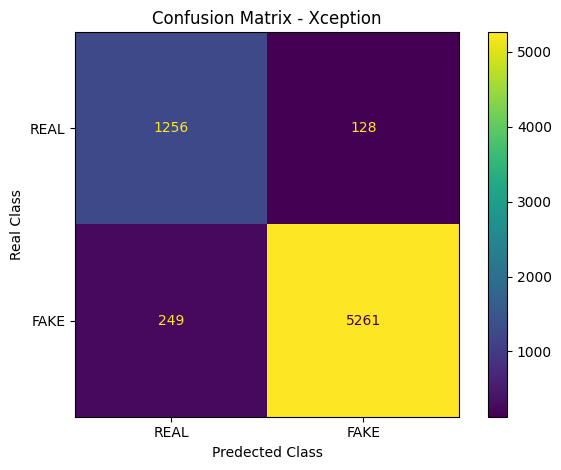

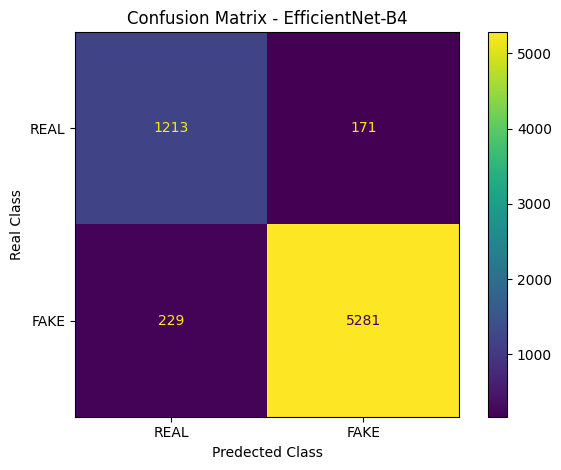

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np


# ============================================================
# XCEPTION
# ============================================================

cm_xception = np.array([
    [1256, 128],   # REAL: TN, FP
    [249, 5261]    # FAKE: FN, TP
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xception,
    display_labels=["REAL", "FAKE"]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix - Xception")
plt.xlabel("Predected Class")
plt.ylabel("Real Class")
plt.tight_layout()

plt.savefig(
    "confusion_matrix_xception.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# EFFICIENTNET-B4
# ============================================================

cm_efficientnet = np.array([
    [1213, 171],   # REAL: TN, FP
    [229, 5281]    # FAKE: FN, TP
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_efficientnet,
    display_labels=["REAL", "FAKE"]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix - EfficientNet-B4")
plt.xlabel("Predected Class")
plt.ylabel("Real Class")
plt.tight_layout()

plt.savefig(
    "confusion_matrix_efficientnet_b4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()